In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
hour_df = pd.read_csv('../data/hour_prediction.csv')
hour_df.head()

,Unnamed: 0,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,...,atemp,hum,windspeed,casual,registered,cnt,demand_previousday,demand_previousweek,hourxworkingday,predicted_demand
0,15919,15920,2012-11-01,4,1,11,0,0,4,1,...,0.3636,0.57,0.0896,8,52,60,16.0,76.0,24,54.773737
1,15920,15921,2012-11-01,4,1,11,1,0,4,1,...,0.3182,0.75,0.1045,8,22,30,8.0,28.0,25,14.409759
2,15921,15922,2012-11-01,4,1,11,2,0,4,1,...,0.3333,0.66,0.1343,10,10,20,7.0,18.0,26,8.426482
3,15922,15923,2012-11-01,4,1,11,3,0,4,1,...,0.3333,0.61,0.1343,5,10,15,3.0,8.0,27,7.672983
4,15923,15924,2012-11-01,4,1,11,4,0,4,1,...,0.3485,0.66,0.1045,2,8,10,5.0,5.0,28,12.324972


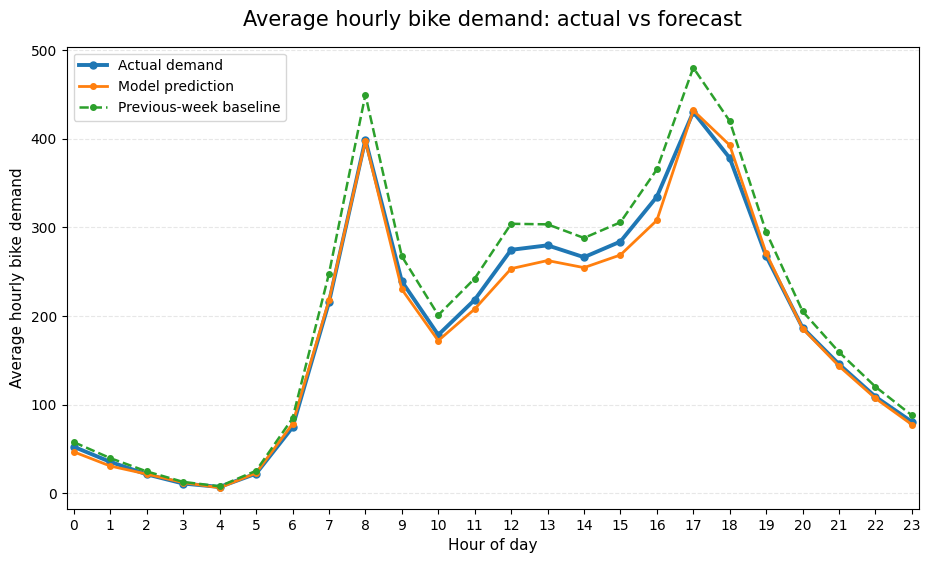

In [5]:
test_period = hour_df[
    (hour_df["dteday"] >= "2012-11-01") &
    (hour_df["dteday"] <= "2012-12-31")
]

hourly = test_period.groupby("hr")[
    ["cnt", "demand_previousweek", "predicted_demand"]
].mean()

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    hourly.index,
    hourly["cnt"],
    marker="o",
    linewidth=2.8,
    markersize=5,
    label="Actual demand",
)

ax.plot(
    hourly.index,
    hourly["predicted_demand"],
    marker="o",
    linewidth=2,
    markersize=4,
    label="Model prediction",
)

ax.plot(
    hourly.index,
    hourly["demand_previousweek"],
    linestyle="--",
    linewidth=1.8,
    marker="o",
    markersize=4,
    label="Previous-week baseline",
)

ax.set_title(
    "Average hourly bike demand: actual vs forecast",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Hour of day", fontsize=11)
ax.set_ylabel("Average hourly bike demand", fontsize=11)

ax.set_xticks(range(0, 24))
ax.set_xlim(-0.2, 23.2)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)
ax.legend()
plt.show()

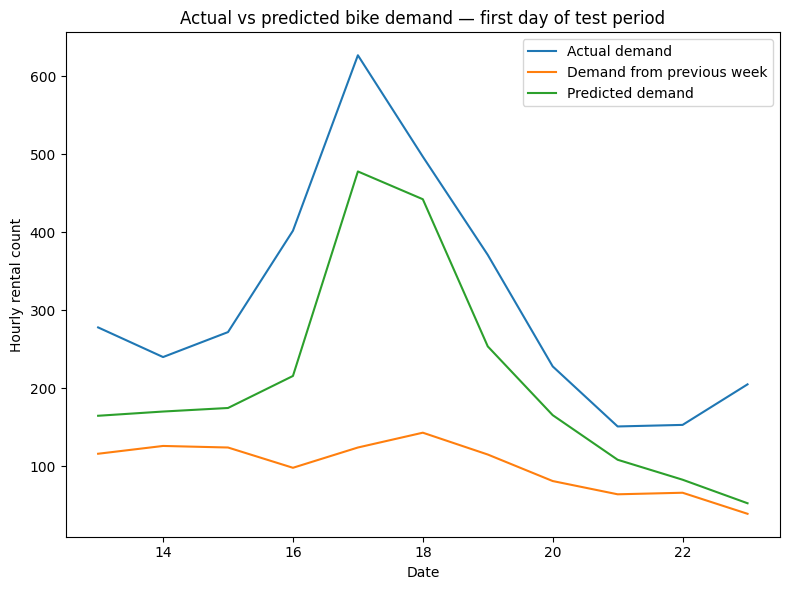

In [6]:
df = hour_df[(hour_df['dteday']=='2012-11-06')]
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    df["hr"],
    df["cnt"],
    label="Actual demand",
)
ax.plot(
    df["hr"],
    df["demand_previousweek"],
    label="Demand from previous week",
)
ax.plot(
    df["hr"],
    df["predicted_demand"],
    label="Predicted demand",
)
ax.set_xlabel("Date")
ax.set_ylabel("Hourly rental count")
ax.set_title("Actual vs predicted bike demand — first day of test period")
ax.legend()
plt.tight_layout()
plt.show()

<Axes: xlabel='hr'>

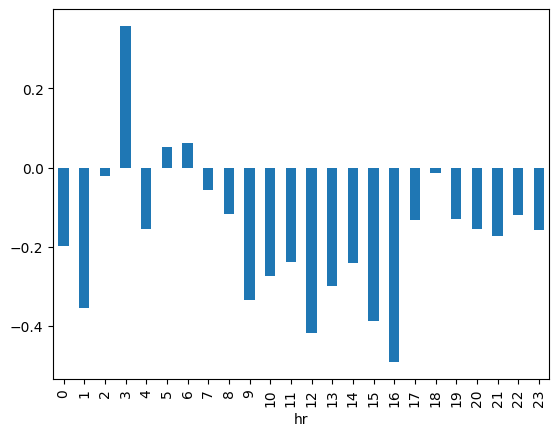

In [7]:
((hour_df[hour_df["workingday"]==1].groupby('hr')['predicted_demand'].mean() 
- hour_df[hour_df["workingday"]==1].groupby('hr')['cnt'].mean())
/hour_df[hour_df["workingday"]==1].groupby('hr')['predicted_demand'].std()).plot(kind='bar')

Text(0, 0.5, 'Mean forecast error (bikes/hour)')

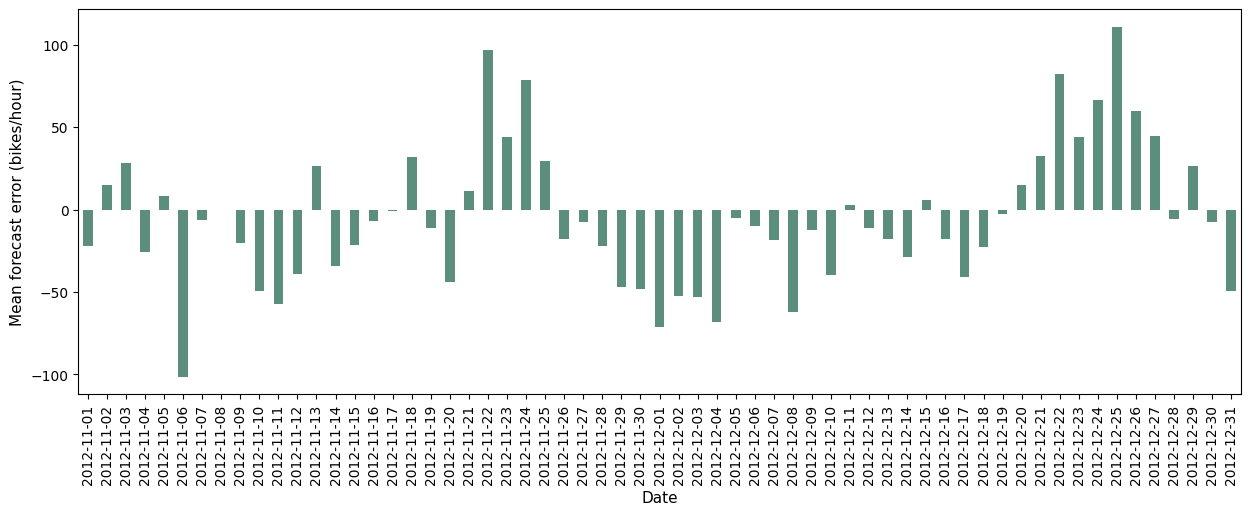

In [8]:
ax = ((hour_df.groupby('dteday')['predicted_demand'].mean() 
- hour_df.groupby('dteday')['cnt'].mean())).plot(kind='bar', figsize=(15,5), color="#5B8E7D")
ax.set_xlabel("Date",fontsize=11)
ax.set_ylabel("Mean forecast error (bikes/hour)",fontsize=11)
#ax.axhline(0, linewidth=1)


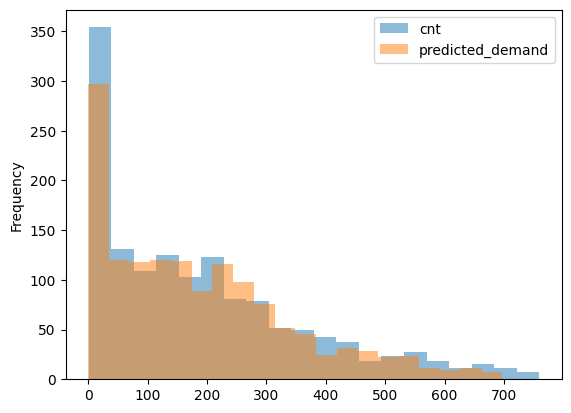

In [9]:
ax = hour_df['cnt'].plot(kind='hist', alpha=0.5, bins=20)
ax = hour_df['predicted_demand'].plot(kind='hist',  alpha=0.5,bins=20)
ax.legend()